In [ ]:
import sys, json
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams.update({'font.size': 11, 'figure.figsize': (14, 6)})

repo_root = Path.cwd()
if not (repo_root / "src").exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root))

from src.indexing.ner_token_index import load_token_index_artifacts
from src.indexing.base import query_index, build_index
from src.smoothing.manifold import ManifoldSmoother
from src.smoothing.pca import fit_local_pca

print("Imports OK")

Imports OK


## 1. Load Pre-built Token Index (train set, last layer)

In [6]:
token_dir = repo_root / "output" / "ner_conll2003_bert" / "token_layer_embeddings" / "train" / "last"
vectors, token_texts, label_ids = load_token_index_artifacts(token_dir)

# Load label map
label_map_path = token_dir / "label_map.json"
if label_map_path.exists():
    with open(label_map_path) as f:
        id2label = {int(k): v for k, v in json.load(f)["id2label"].items()}
else:
    id2label = {0: "O", 1: "B-PER", 2: "I-PER", 3: "B-ORG", 4: "I-ORG",
                5: "B-LOC", 6: "I-LOC", 7: "B-MISC", 8: "I-MISC"}

label_names = [id2label.get(lid, str(lid)) for lid in label_ids]

print(f"Loaded {vectors.shape[0]} token vectors, dim={vectors.shape[1]}")
print(f"Labels: {sorted(set(label_names))}")

# Build torch index for fast lookup
index = build_index(vectors=vectors, backend="torch", metric="euclidean")
print("Index built.")

Loaded 15626 token vectors, dim=768
Labels: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER', 'O']
Index built.


##  Load NER Classifier Head (for actual label predictions)

load **only the classifier linear layer** from the checkpoint 
The hidden states in the index ARE the last-layer outputs, so `classifier(hidden_state)` gives the real NER prediction.

In [7]:
import torch.nn as nn

# Load checkpoint — only need classifier weights
ckpt_path = repo_root / "output" / "ner_conll2003_bert" / "ner_bert_conll2003_finetune" / "model.pt"
checkpoint = torch.load(ckpt_path, map_location="cpu")
state_dict = checkpoint.get("model_state_dict", checkpoint.get("state_dict", checkpoint))

# Extract classifier layer dimensions
cls_weight = state_dict["classifier.weight"]  # (num_labels, hidden_dim)
cls_bias = state_dict["classifier.bias"]      # (num_labels,)
num_labels = cls_weight.shape[0]
hidden_dim = cls_weight.shape[1]

# Build standalone classifier (single linear layer — no BERT needed)
classifier = nn.Linear(hidden_dim, num_labels)
classifier.weight = nn.Parameter(cls_weight)
classifier.bias = nn.Parameter(cls_bias)
classifier.eval()

print(f"Classifier loaded: {hidden_dim} → {num_labels} labels")
print(f"Labels: {id2label}")

def classify_vectors(vecs):
    """Classify hidden-state vectors using the actual NER classifier head.
    
    Args:
        vecs: numpy array (N, D) or (D,)
    Returns:
        list of predicted label names
    """
    if vecs.ndim == 1:
        vecs = vecs.reshape(1, -1)
    with torch.no_grad():
        logits = classifier(torch.as_tensor(vecs, dtype=torch.float32))
        pred_ids = logits.argmax(dim=-1).tolist()
    return [id2label.get(p, str(p)) for p in pred_ids]

# # Quick sanity check: classify original selected tokens
# for target, (idx, tok, vec, lbl) in selected_tokens.items():
#     pred = classify_vectors(vec)[0]
#     match = "✓" if pred == lbl else "✗"
#     print(f"  {tok:15s}  true={lbl:8s}  pred={pred:8s}  {match}")

Classifier loaded: 768 → 9 labels
Labels: {0: 'O', 1: 'B-PER', 2: 'I-PER', 3: 'B-ORG', 4: 'I-ORG', 5: 'B-LOC', 6: 'I-LOC', 7: 'B-MISC', 8: 'I-MISC'}


## 2. Pick Random Tokens  Per Entity Type

In [8]:
rng = np.random.default_rng(18)

target_labels = ["B-PER", "B-ORG", "B-LOC", "B-MISC", "O",]
# "I-PER","I-ORG","I-LOC","I-MISC"
selected_tokens = {}  # label -> (idx, token_text, vector)

for target in target_labels:
    candidates = [i for i, ln in enumerate(label_names) if ln == target]
    if candidates:
        idx = rng.choice(candidates)
        selected_tokens[target] = (idx, token_texts[idx], vectors[idx], label_names[idx])
        print(f"{target:8s} → idx={idx:6d}  token='{token_texts[idx]}'")

print(f"\nSelected {len(selected_tokens)} tokens for visualization.")

B-PER    → idx= 13475  token='kapoor'
B-ORG    → idx=  7983  token='fa'
B-LOC    → idx=  2712  token='houston'
B-MISC   → idx= 12467  token='democrat'
O        → idx= 13318  token='efficiency'

Selected 5 tokens for visualization.


## 3. Visualization Functions

In [13]:
from collections import Counter
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

# Stronger, more saturated colors
LABEL_COLORS = {
    "O": "#888888", 
    "B-PER": "#d62728", "I-PER": "#e74c3c",
    "B-ORG": "#1f77b4", "I-ORG": "#3498db",
    "B-LOC": "#2ca02c", "I-LOC": "#27ae60",
    "B-MISC": "#e67e22", "I-MISC": "#f39c12",
}

# Short labels for compact display
LABEL_SHORT = {
    "O": "O", "B-PER": "PER", "I-PER": "PER", "B-ORG": "ORG", "I-ORG": "ORG",
    "B-LOC": "LOC", "I-LOC": "LOC", "B-MISC": "MISC", "I-MISC": "MISC",
}

ALL_LABELS = ["O", "B-PER", "I-PER", "B-ORG", "I-ORG", "B-LOC", "I-LOC", "B-MISC", "I-MISC"]
FLIP_COLOR = "#1a1a1a"  # near-black for label flips

N_ANNOTATE = 35  # how many points get a text label

def get_nearest_token(vec, index, token_texts, label_names, top_k=1):
    ids = query_index(index, k=top_k, vector=vec)
    results = [(token_texts[int(i)], label_names[int(i)]) for i in ids]
    return results[0] if top_k == 1 else results

def decode_vectors(vecs, index, token_texts, label_names):
    if vecs.ndim == 1:
        vecs = vecs.reshape(1, -1)
    nn_toks = [get_nearest_token(v, index, token_texts, label_names)[0] for v in vecs]
    pred_labels = classify_vectors(vecs)
    return list(zip(nn_toks, pred_labels))

def project_to_local_pca_2d(points, pca):
    centered = points - pca.mean
    return centered @ pca.evecs[:, :2]


def _build_legend(ax, labels_present, mode="neighborhood"):
    """Compact legend: shapes + NER colors."""
    handles = []
    handles.append(Line2D([0], [0], marker='*', color='w', markerfacecolor='gold',
                          markeredgecolor='k', markersize=12, label='Anchor'))
    if mode == "neighborhood":
        pass
    elif mode == "gaussian":
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaa',
                              markeredgecolor='k', markersize=6, label='Same label'))
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=FLIP_COLOR,
                              markeredgecolor='k', markersize=6, label='Label flip'))
    elif mode == "manifold":
        handles.append(Line2D([0], [0], marker='D', color='w', markerfacecolor='#ccc',
                              markeredgecolor='gray', markersize=5, label='kNN neighbor'))
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor='#aaa',
                              markeredgecolor='k', markersize=6, label='Same label'))
        handles.append(Line2D([0], [0], marker='o', color='w', markerfacecolor=FLIP_COLOR,
                              markeredgecolor='k', markersize=6, label='Label flip'))
    for lbl in ALL_LABELS:
        if lbl in labels_present:
            handles.append(mpatches.Patch(color=LABEL_COLORS[lbl], label=lbl))
    ax.legend(handles=handles, loc='upper right', fontsize=6, ncol=2,
              framealpha=0.9, handletextpad=0.3, columnspacing=0.5,
              borderpad=0.3, labelspacing=0.25)


def _dist_text(ax, lbl_counts):
    dist_str = "  ".join(f"{l}:{n}" for l, n in lbl_counts.most_common())
    ax.text(0.02, 0.02, dist_str, transform=ax.transAxes, fontsize=7,
            verticalalignment='bottom', bbox=dict(boxstyle='round', fc='wheat', alpha=0.85))


def _plot_samples_on_ax(ax, anchor_vec, anchor_text, anchor_label, pca_viz,
                        sample_vecs, index, token_texts, label_names,
                        neighbor_vecs=None, neighbor_lbls=None,
                        n_samples=100, title="", mode="gaussian"):
    """Shared helper to plot decoded samples on an axis with a given PCA basis."""
    decoded = decode_vectors(sample_vecs, index, token_texts, label_names)
    decoded_toks = [d[0] for d in decoded]
    decoded_lbls = [d[1] for d in decoded]

    parts = [anchor_vec.reshape(1, -1)]
    if neighbor_vecs is not None:
        parts.append(neighbor_vecs)
    parts.append(sample_vecs)
    all_pts = np.vstack(parts)
    proj = project_to_local_pca_2d(all_pts, pca_viz)

    p_anchor = proj[0]
    offset = 1
    if neighbor_vecs is not None:
        p_neighbors = proj[offset:offset + len(neighbor_vecs)]
        offset += len(neighbor_vecs)
        for i in range(len(neighbor_vecs)):
            c = LABEL_COLORS.get(neighbor_lbls[i], "#333333")
            ax.scatter(p_neighbors[i, 0], p_neighbors[i, 1], c=c, s=18, alpha=0.2,
                       edgecolors='gray', linewidths=0.2, marker='D')
    p_samples = proj[offset:]

    for i in range(len(sample_vecs)):
        same = decoded_lbls[i] == anchor_label
        if same:
            c = LABEL_COLORS.get(decoded_lbls[i], "#333333")
            ax.scatter(p_samples[i, 0], p_samples[i, 1], c=c, s=60, alpha=0.65, marker='o',
                       edgecolors='k', linewidths=0.3)
        else:
            ax.scatter(p_samples[i, 0], p_samples[i, 1], c=FLIP_COLOR, s=65, alpha=0.85, marker='o',
                       edgecolors='k', linewidths=0.5)

    annotate_idx = np.random.choice(len(sample_vecs), size=min(N_ANNOTATE, len(sample_vecs)), replace=False)
    for i in annotate_idx:
        ax.annotate(decoded_toks[i], (p_samples[i, 0], p_samples[i, 1]),
                    fontsize=7, alpha=0.85, textcoords='offset points', xytext=(4, 4),
                    bbox=dict(boxstyle='round,pad=0.15', fc='white', alpha=0.65, lw=0))

    c = LABEL_COLORS.get(anchor_label, "#333333")
    ax.scatter(p_anchor[0], p_anchor[1], c=c, s=400, marker='*', edgecolors='k', linewidths=1.5, zorder=10)
    ax.annotate(f"★ {anchor_text}", (p_anchor[0], p_anchor[1]),
                fontsize=10, fontweight='bold', textcoords='offset points', xytext=(8, 8),
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.85, lw=0))

    same_count = sum(1 for l in decoded_lbls if l == anchor_label)
    same_tok_count = sum(1 for t in decoded_toks if t == anchor_text)
    _dist_text(ax, Counter(decoded_lbls))
    all_labels_present = set(decoded_lbls) | {anchor_label}
    if neighbor_lbls is not None:
        all_labels_present |= set(neighbor_lbls)
    _build_legend(ax, all_labels_present, mode=mode)
    ax.set_title(f"{title}\nLabel preserved: {same_count}/{n_samples} · Same token: {same_tok_count}/{n_samples}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.2)


# ============================================================
# PLOT A — kNN Neighborhood
# ============================================================
def plot_neighborhood(ax, anchor_vec, anchor_text, anchor_label,
                      index, token_texts, label_names, knn_k=200, title=""):
    neighbor_ids = query_index(index, k=knn_k + 1, vector=anchor_vec)
    neighbor_ids = neighbor_ids[1:]
    neighbor_vecs = vectors[neighbor_ids]
    neighbor_toks = [token_texts[int(i)] for i in neighbor_ids]
    neighbor_lbls = classify_vectors(neighbor_vecs)

    pca = fit_local_pca(neighbor_vecs)
    all_pts = np.vstack([anchor_vec.reshape(1, -1), neighbor_vecs])
    proj = project_to_local_pca_2d(all_pts, pca)

    for i in range(len(neighbor_ids)):
        c = LABEL_COLORS.get(neighbor_lbls[i], "#333333")
        ax.scatter(proj[i+1, 0], proj[i+1, 1], c=c, s=70, alpha=0.7,
                   edgecolors='k', linewidths=0.3, marker='o')

    for i in range(min(N_ANNOTATE, len(neighbor_ids))):
        ax.annotate(neighbor_toks[i], (proj[i+1, 0], proj[i+1, 1]),
                    fontsize=7, fontweight='bold', alpha=0.9,
                    textcoords='offset points', xytext=(5, 5),
                    bbox=dict(boxstyle='round,pad=0.2', fc='white', alpha=0.7, lw=0))

    c = LABEL_COLORS.get(anchor_label, "#333333")
    ax.scatter(proj[0, 0], proj[0, 1], c=c, s=400, marker='*', edgecolors='k', linewidths=1.5, zorder=10)
    ax.annotate(f"★ {anchor_text}", (proj[0, 0], proj[0, 1]),
                fontsize=10, fontweight='bold', textcoords='offset points', xytext=(8, 8),
                bbox=dict(boxstyle='round,pad=0.3', fc='yellow', alpha=0.85, lw=0))

    _dist_text(ax, Counter(neighbor_lbls))
    _build_legend(ax, set(neighbor_lbls) | {anchor_label}, mode="neighborhood")
    ax.set_title(f"{title}\n{knn_k} neighbors", fontsize=12, fontweight='bold')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.grid(True, alpha=0.2)
    return pca


# ============================================================
# PLOT B — Gaussian Smoothing
# ============================================================
def plot_gaussian_smoothing(ax, anchor_vec, anchor_text, anchor_label,
                            pca, index, token_texts, label_names,
                            sigma=0.5, n_samples=100, title=""):
    noise = np.random.randn(n_samples, anchor_vec.shape[0]).astype(np.float32) * sigma
    noisy_vecs = anchor_vec.reshape(1, -1) + noise
    _plot_samples_on_ax(ax, anchor_vec, anchor_text, anchor_label, pca,
                        noisy_vecs, index, token_texts, label_names,
                        n_samples=n_samples, title=title, mode="gaussian")


# ============================================================
# PLOT C — Manifold Smoothing (with whitening)
# ============================================================
def plot_manifold_smoothing(ax, anchor_vec, anchor_text, anchor_label,
                            pca_viz, smoother, index, token_texts, label_names,
                            knn_k=200, n_samples=100, title=""):
    neighbor_ids = query_index(index, k=knn_k + 1, vector=anchor_vec)[1:]
    neighbor_vecs = vectors[neighbor_ids]
    neighbor_lbls = classify_vectors(neighbor_vecs)
    manifold_samples = smoother.sample_n(anchor_vec, n_samples)
    _plot_samples_on_ax(ax, anchor_vec, anchor_text, anchor_label, pca_viz,
                        manifold_samples, index, token_texts, label_names,
                        neighbor_vecs=neighbor_vecs, neighbor_lbls=neighbor_lbls,
                        n_samples=n_samples, title=title, mode="manifold")


# ============================================================
# PLOT D — Manifold Smoothing WITHOUT whitening
# ============================================================
def plot_manifold_no_whiten(ax, anchor_vec, anchor_text, anchor_label,
                            pca_viz, index, token_texts, label_names,
                            sigma=0.5, knn_k=200, n_samples=100, title=""):
    """Sample on the local PCA subspace WITHOUT whitening the covariance."""
    neighbor_ids = query_index(index, k=knn_k + 1, vector=anchor_vec)[1:]
    neighbor_vecs = vectors[neighbor_ids]
    neighbor_lbls = classify_vectors(neighbor_vecs)

    # Fit local PCA on neighbors
    local_pca = fit_local_pca(neighbor_vecs)
    d = min(knn_k, neighbor_vecs.shape[1])

    # Project anchor into PCA subspace, add ISOTROPIC noise (no eigenvalue scaling),
    # project back. Constrains noise to the subspace but doesn't shape it by λ.
    # Compare to whitened version where unwhitening scales noise by √λ → ellipse.
    anchor_centered = anchor_vec - local_pca.mean
    coeffs = anchor_centered @ local_pca.evecs[:, :d]  # (d,)
    noise = np.random.randn(n_samples, d).astype(np.float32) * sigma
    sample_coeffs = coeffs[None, :] + noise  # (n_samples, d)
    manifold_samples = (sample_coeffs @ local_pca.evecs[:, :d].T + local_pca.mean).astype(np.float32)

    _plot_samples_on_ax(ax, anchor_vec, anchor_text, anchor_label, pca_viz,
                        manifold_samples, index, token_texts, label_names,
                        neighbor_vecs=neighbor_vecs, neighbor_lbls=neighbor_lbls,
                        n_samples=n_samples, title=title, mode="manifold")


print("Visualization functions defined (4 plots: neighborhood, gaussian, manifold, manifold-no-whiten).")

Visualization functions defined (4 plots: neighborhood, gaussian, manifold, manifold-no-whiten).


## 4. Generate Token Neighbourhood and Samples 

In [12]:
SIGMA = 0.5
KNN_K = 200
N_SAMPLES = 100


smoother = ManifoldSmoother(sigma=SIGMA, index=index, knn_k=KNN_K, eps_eig=1e-6)

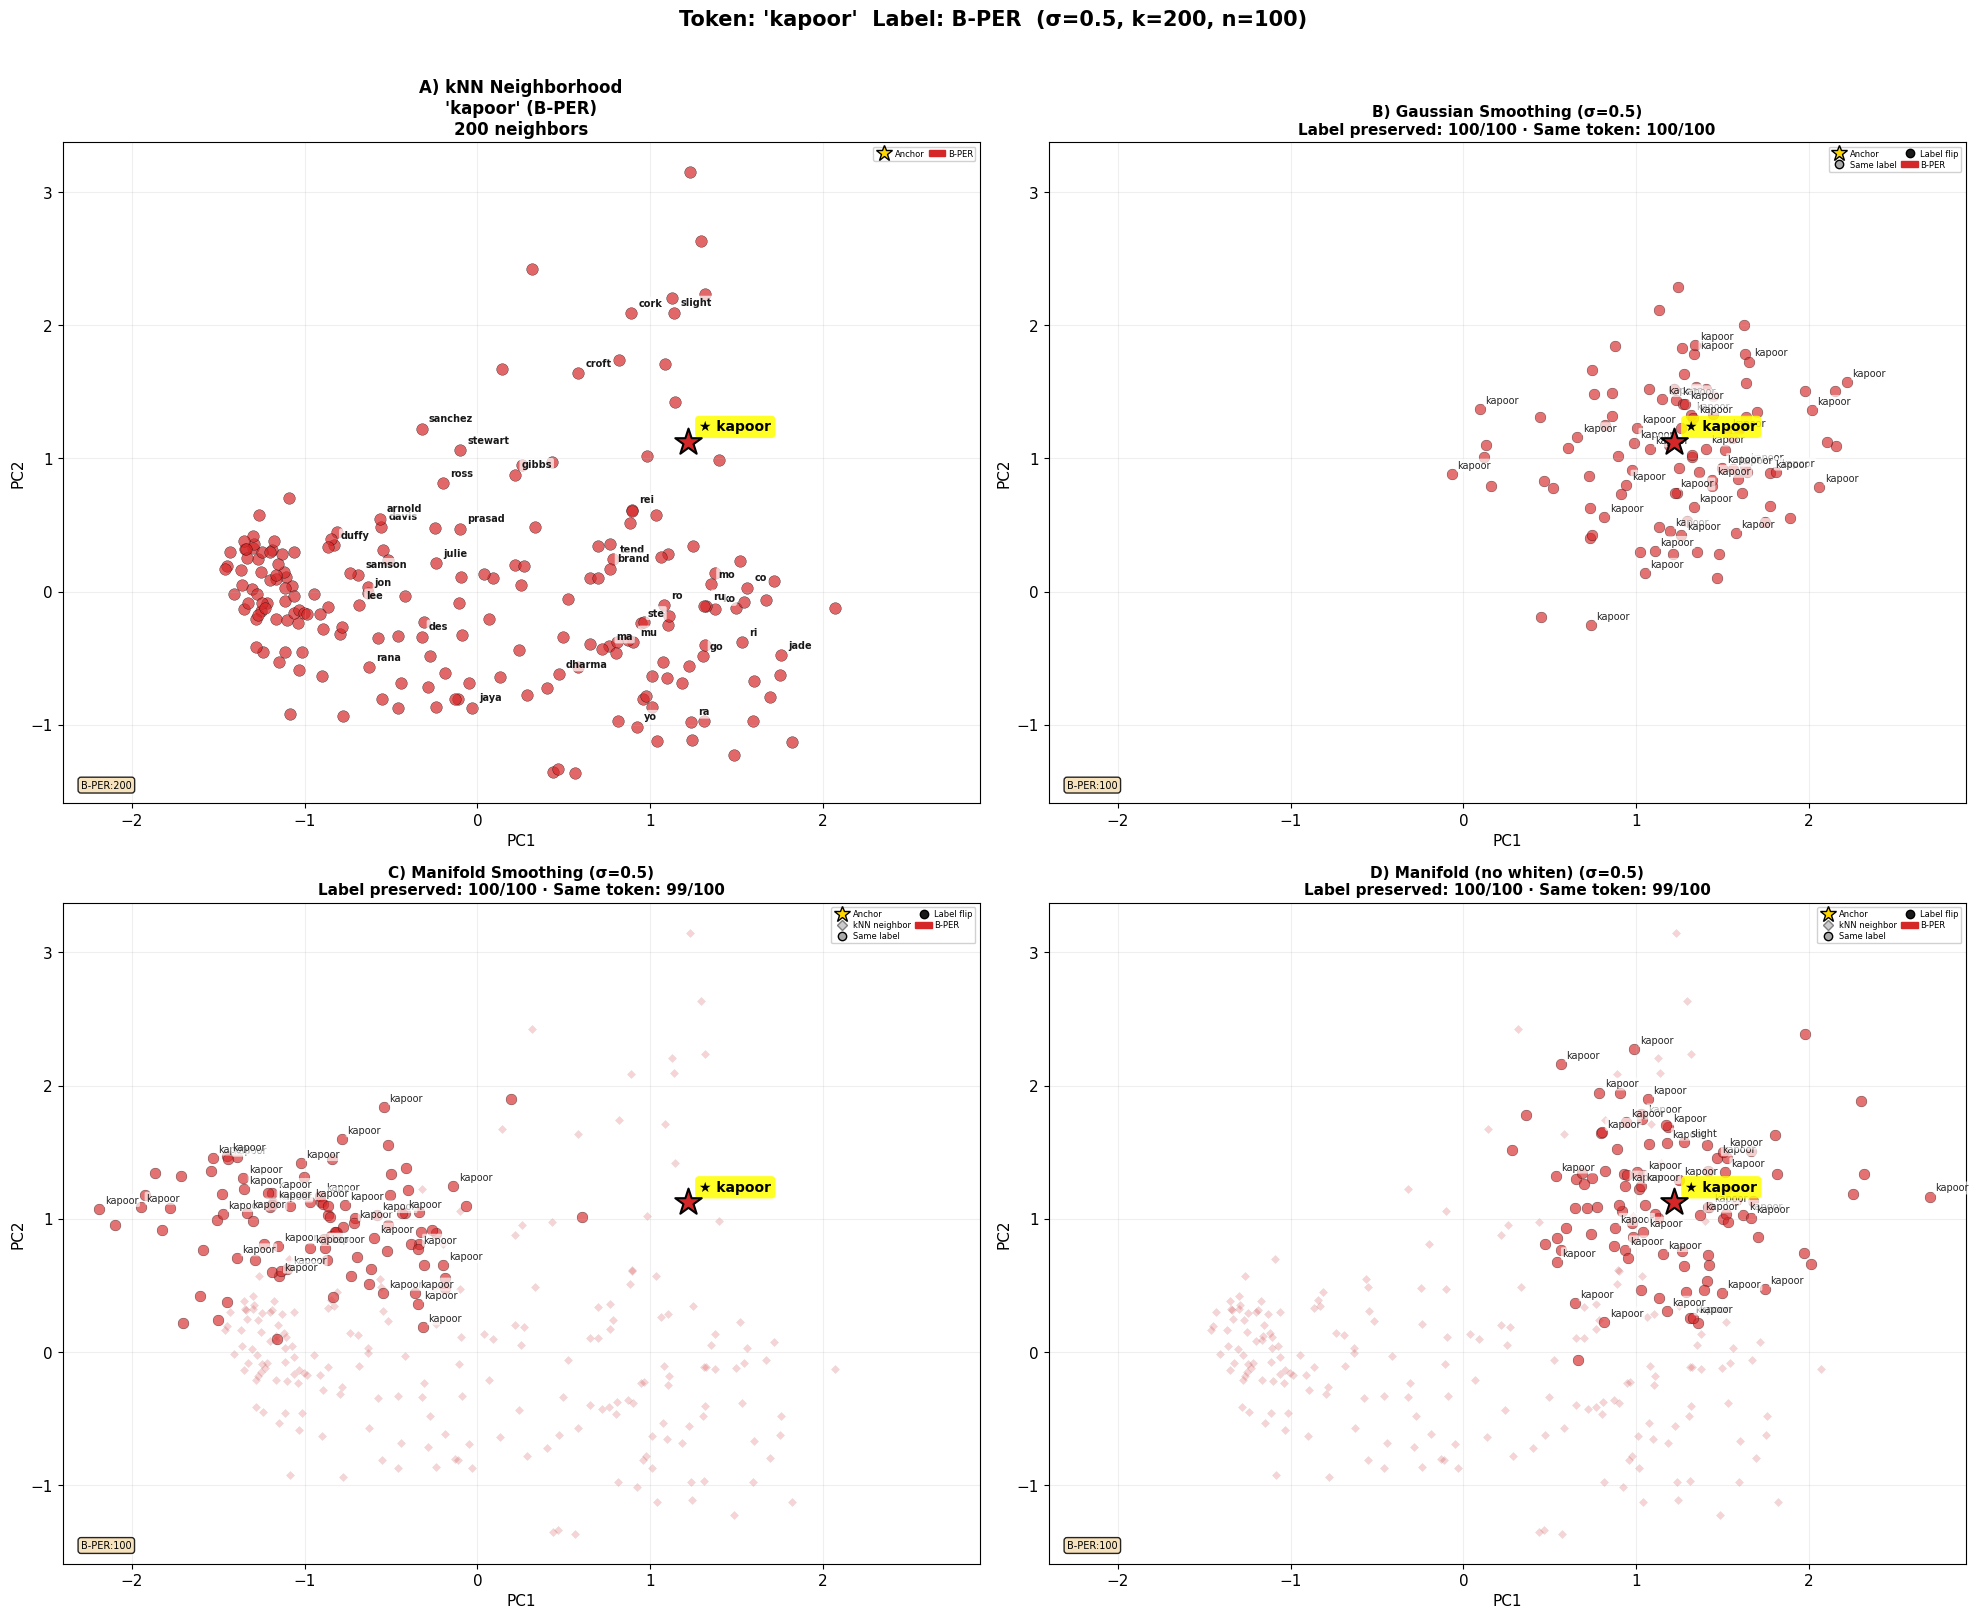

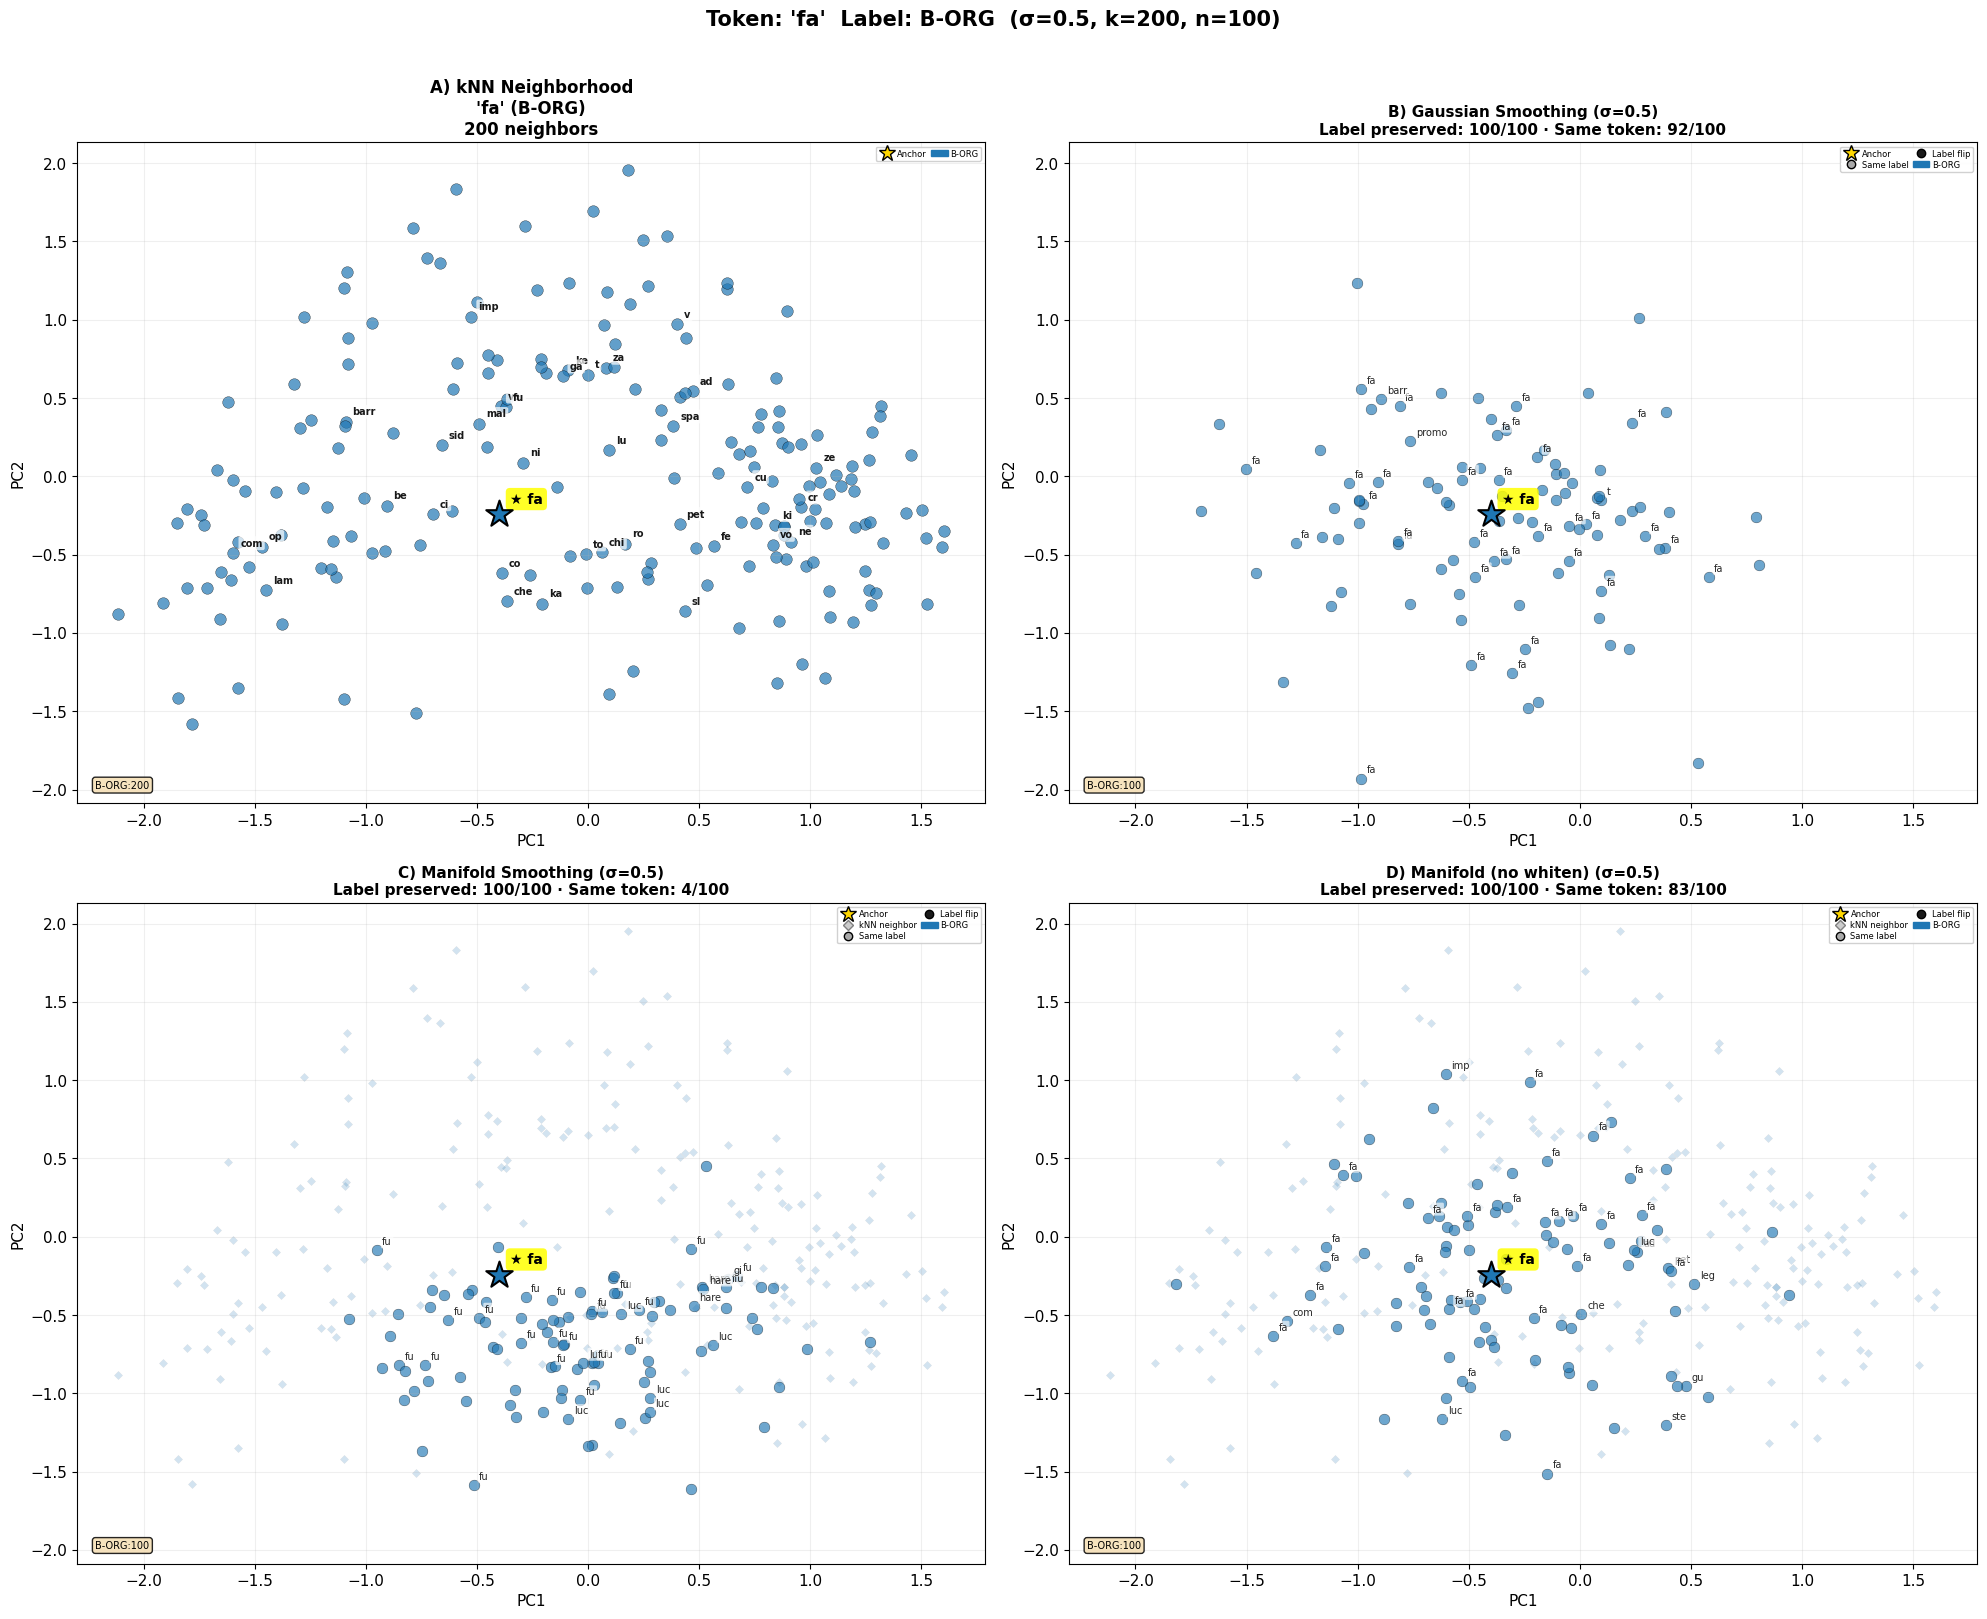

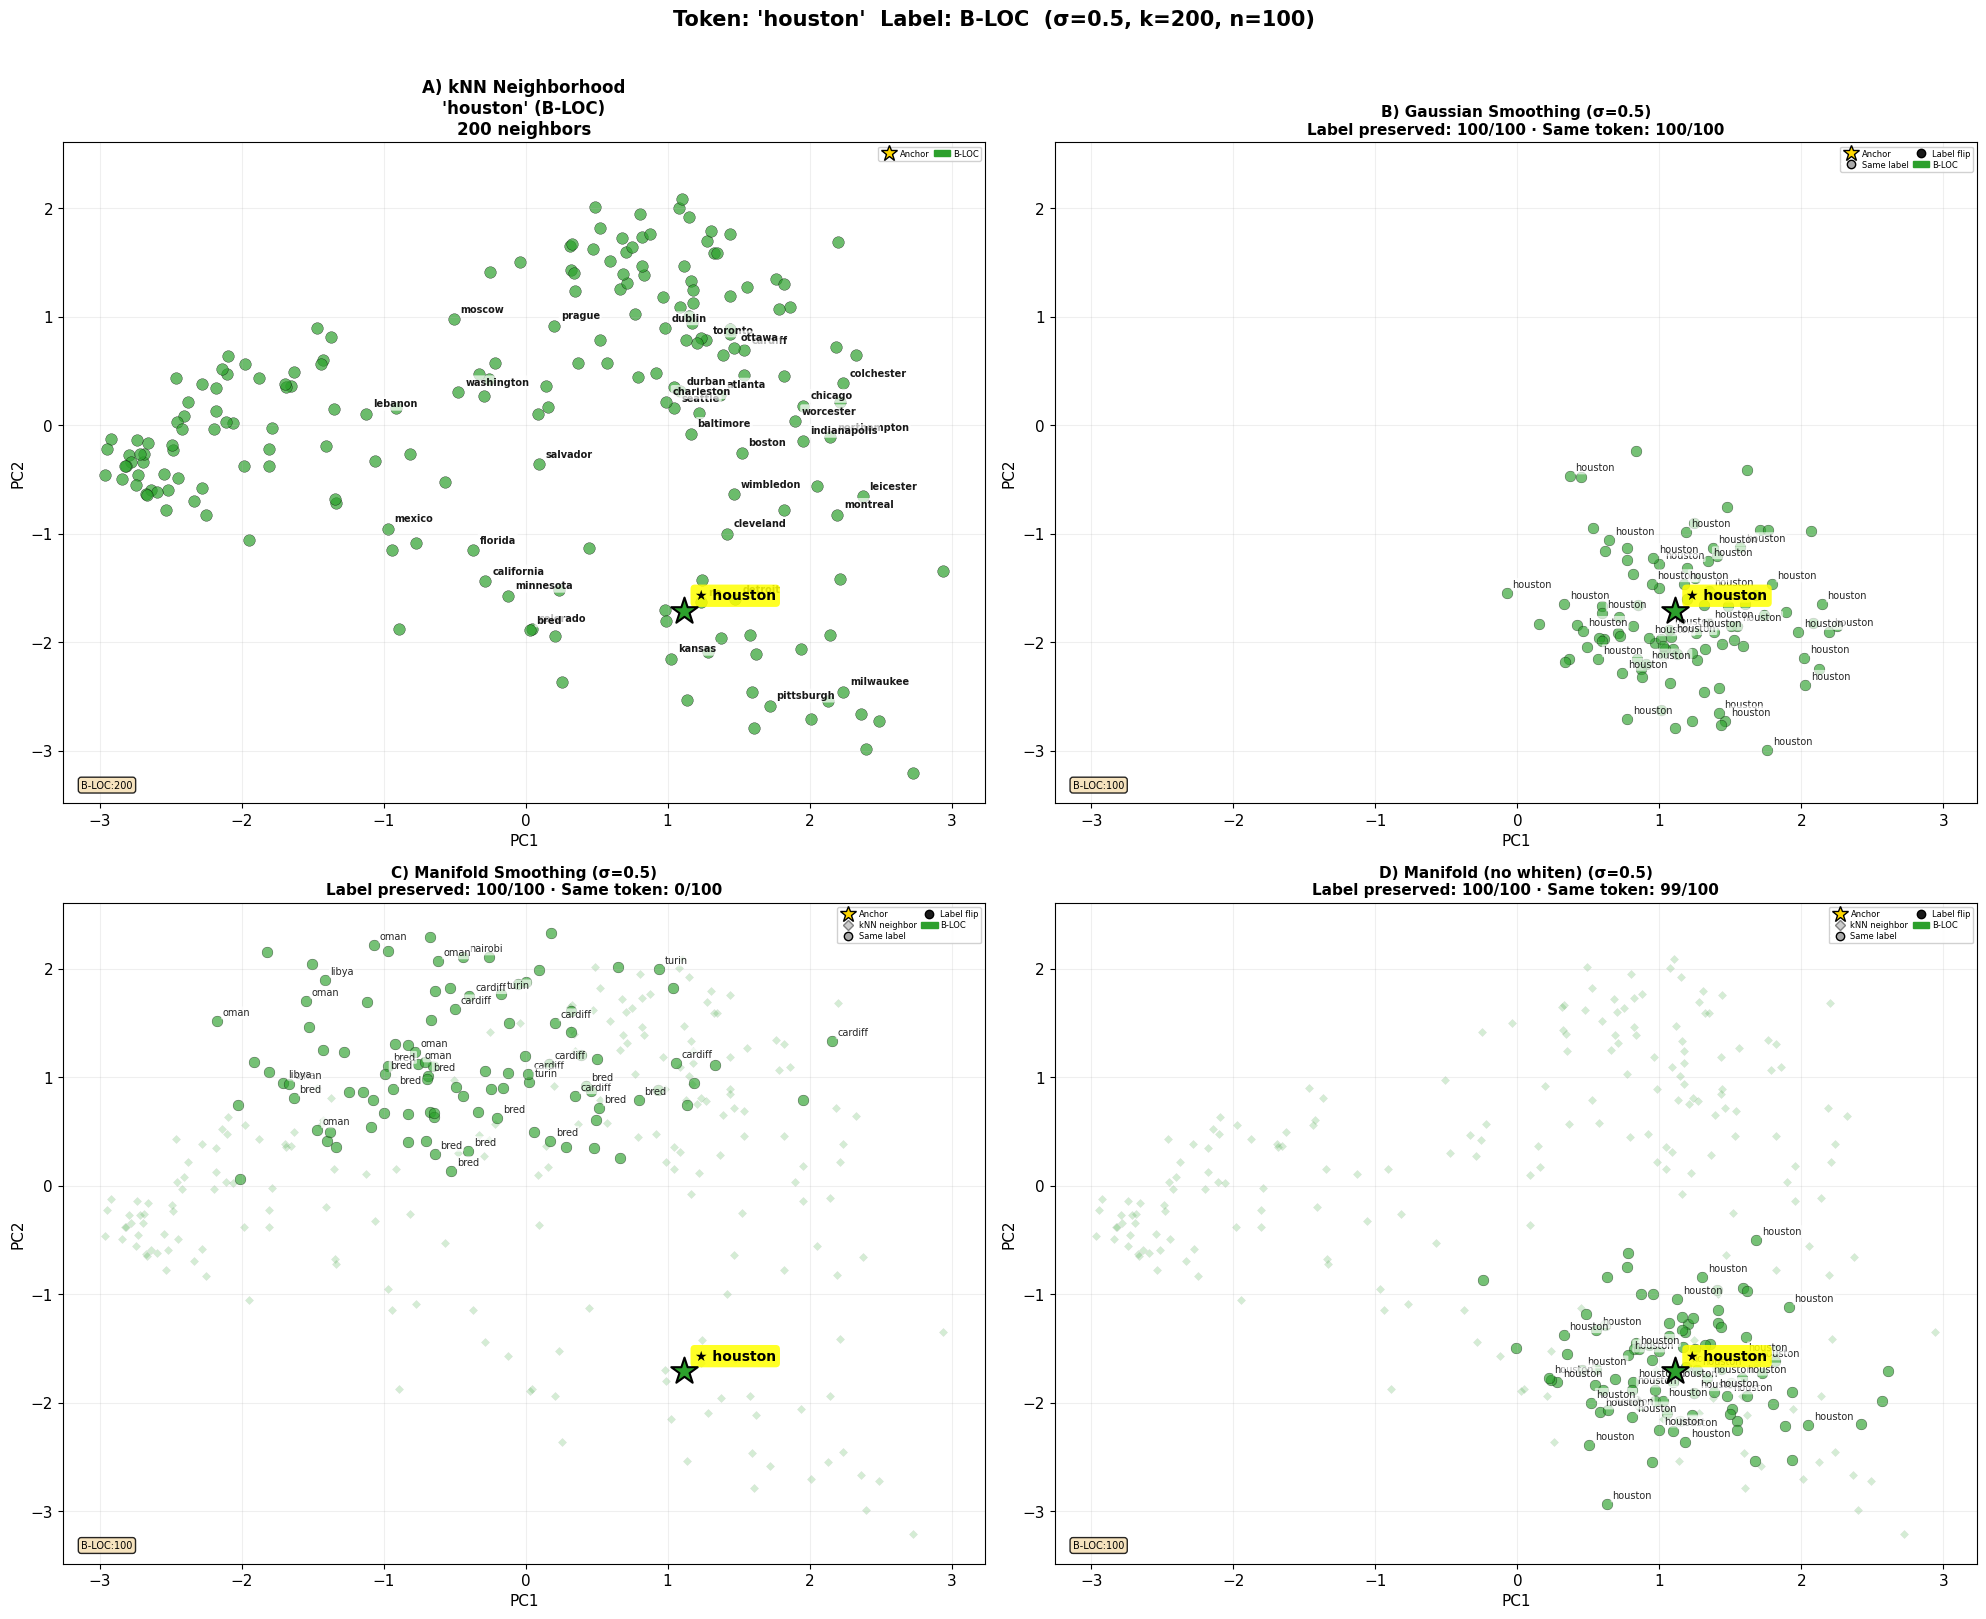

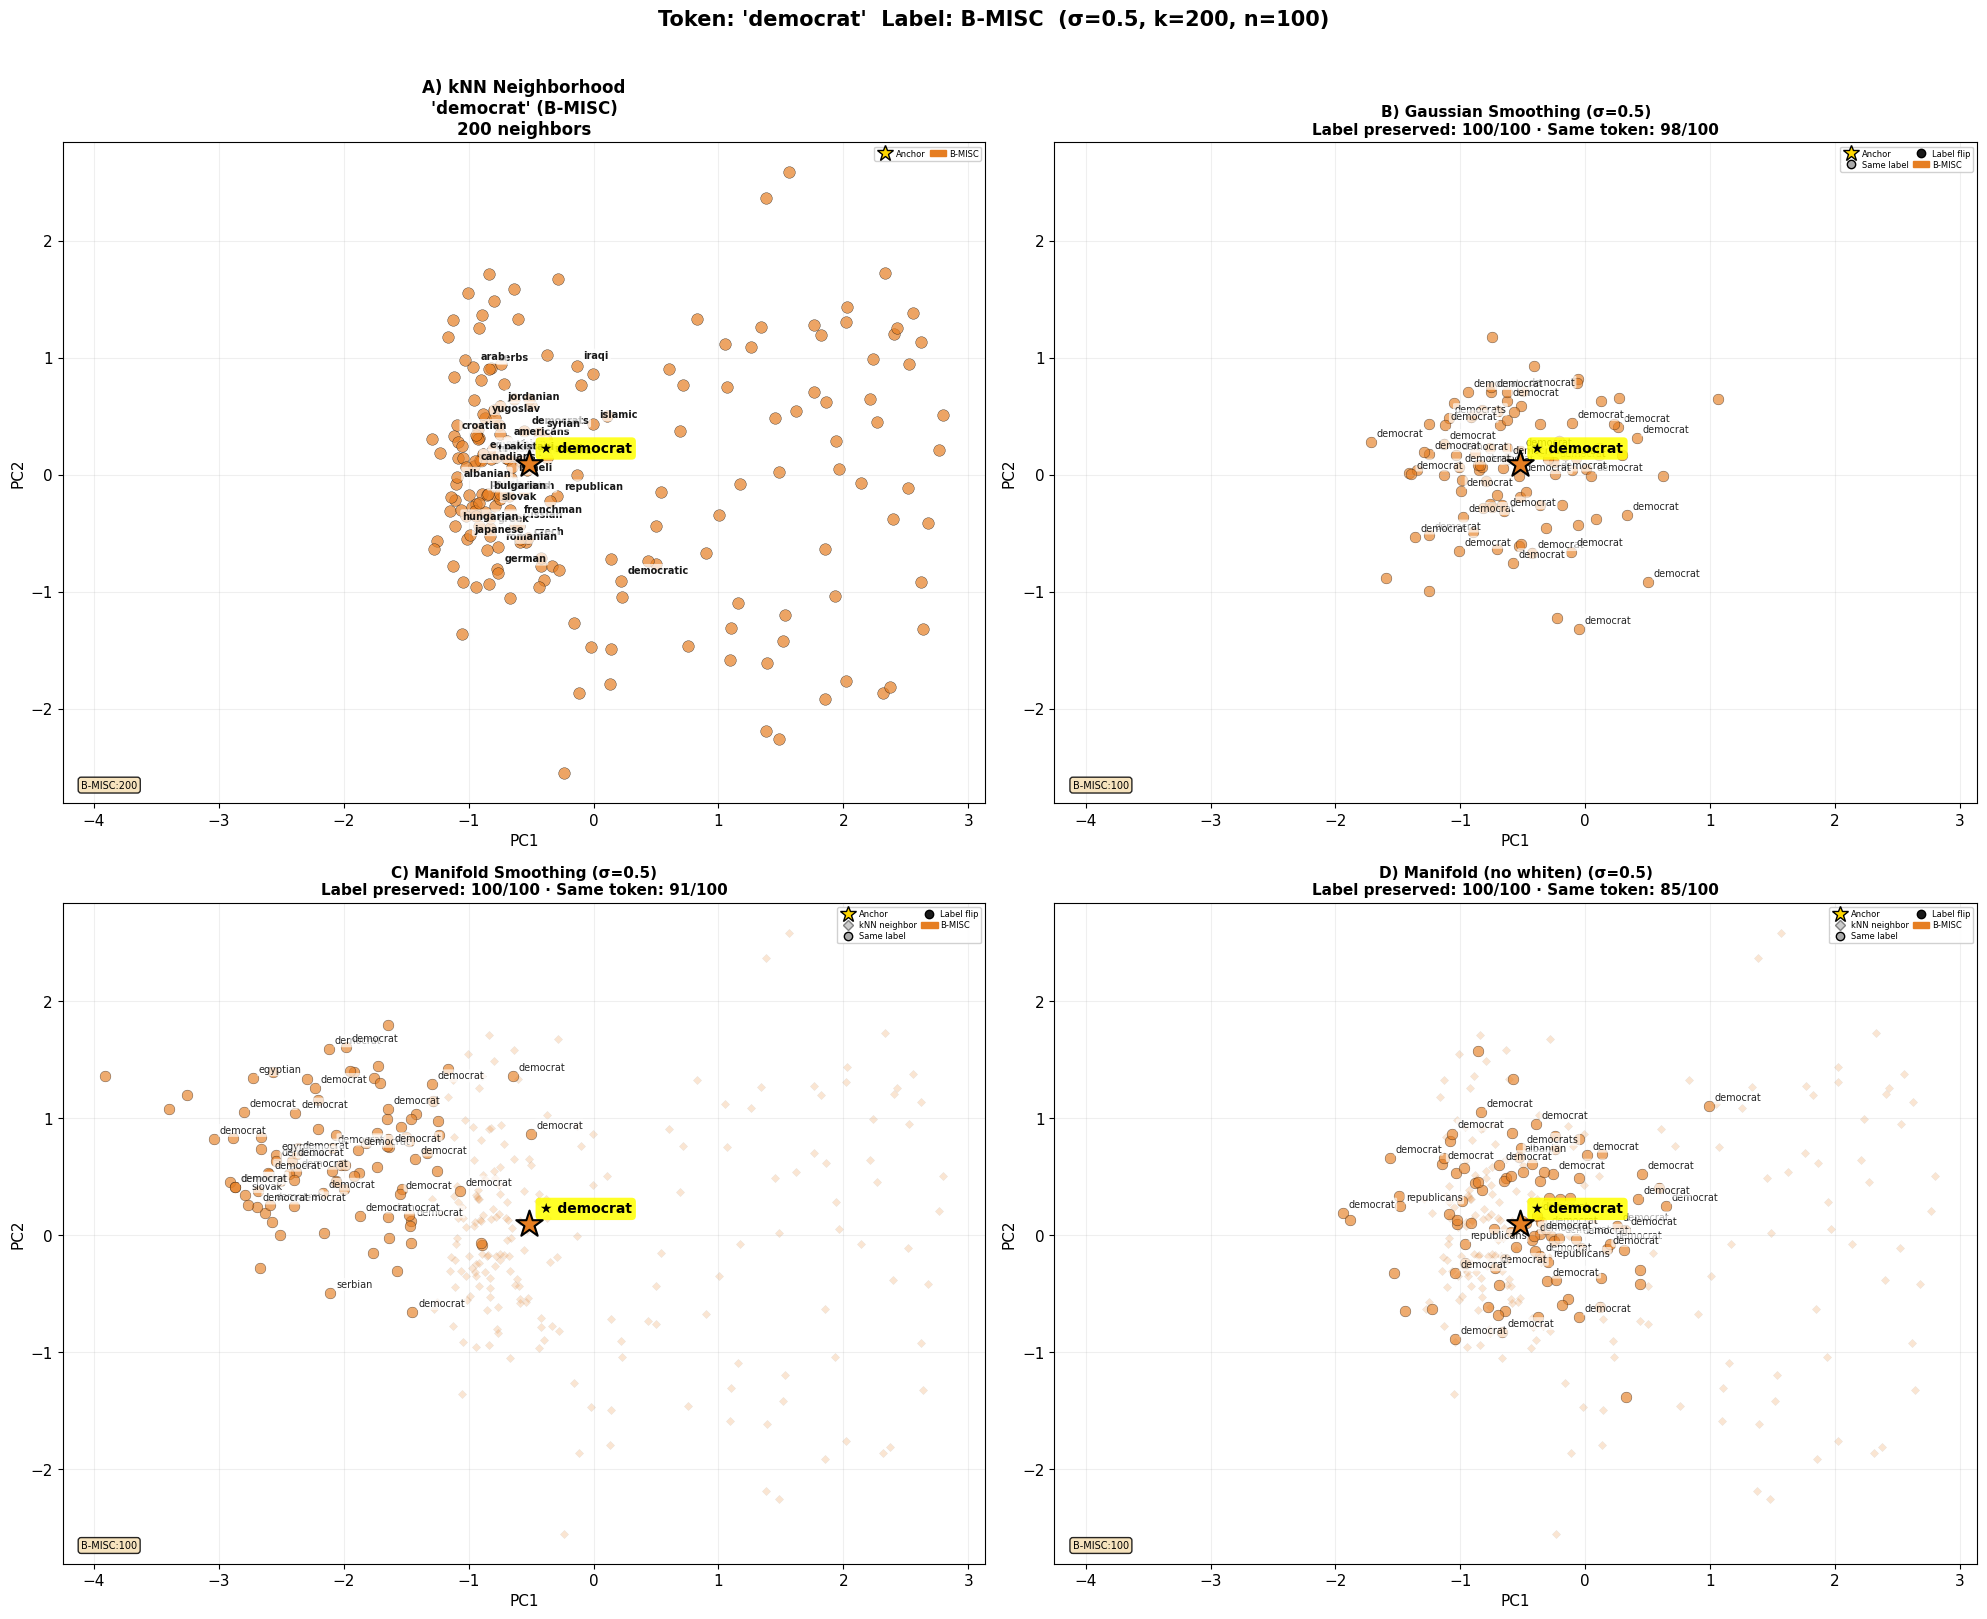

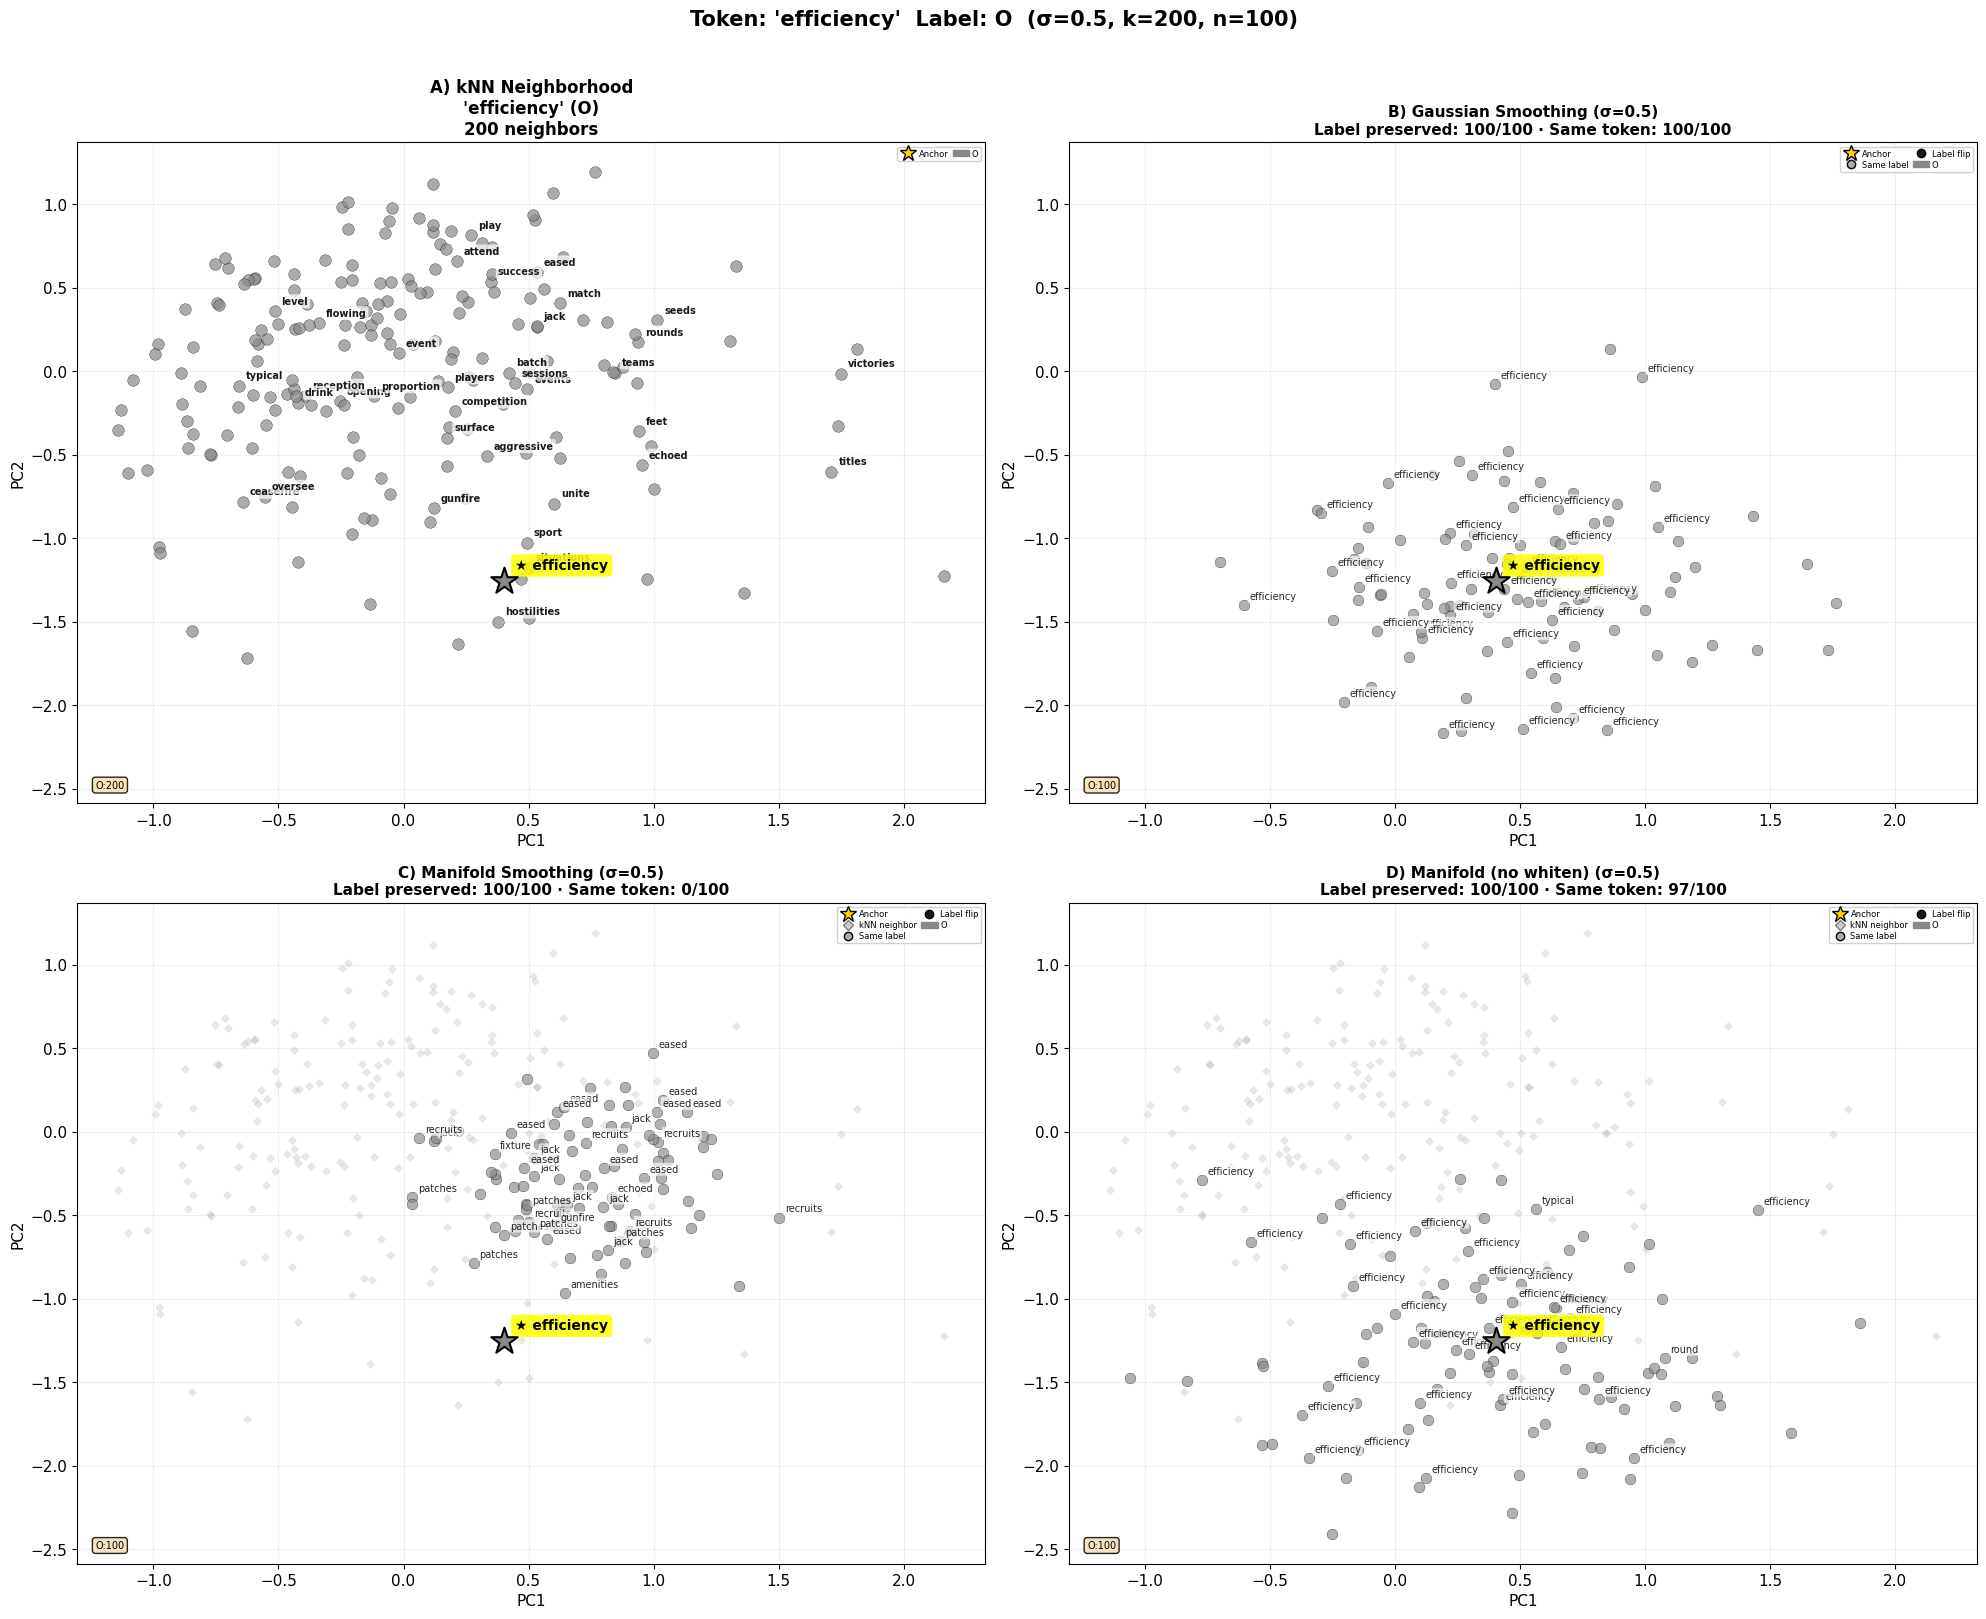

In [ ]:
for target_label, (idx, tok, vec, lbl) in selected_tokens.items():
    fig, axes = plt.subplots(2, 2, figsize=(20, 16))

    # A) kNN Neighborhood  (top-left)
    pca_viz = plot_neighborhood(
        axes[0, 0], vec, tok, lbl, index, token_texts, label_names,
        knn_k=KNN_K, title=f"A) kNN Neighborhood\n'{tok}' ({lbl})")

    # B) Gaussian Smoothing  (top-right)
    plot_gaussian_smoothing(
        axes[0, 1], vec, tok, lbl, pca_viz, index, token_texts, label_names,
        sigma=SIGMA, n_samples=N_SAMPLES,
        title=f"B) Gaussian Smoothing (σ={SIGMA})")

    # C) Manifold Smoothing — with whitening  (bottom-left)
    plot_manifold_smoothing(
        axes[1, 0], vec, tok, lbl, pca_viz, smoother, index, token_texts, label_names,
        knn_k=KNN_K, n_samples=N_SAMPLES,
        title=f"C) Manifold Smoothing (σ={SIGMA})")

    # D) Manifold Smoothing — NO whitening  (bottom-right)
    plot_manifold_no_whiten(
        axes[1, 1], vec, tok, lbl, pca_viz, index, token_texts, label_names,
        sigma=SIGMA, knn_k=KNN_K, n_samples=N_SAMPLES,
        title=f"D) Manifold (no whiten) (σ={SIGMA})")

    # ---- Force identical axis limits across all 4 panels ----
    all_ax = list(axes.flat)
    all_xlims = [a.get_xlim() for a in all_ax]
    all_ylims = [a.get_ylim() for a in all_ax]
    xmin = min(lo for lo, hi in all_xlims)
    xmax = max(hi for lo, hi in all_xlims)
    ymin = min(lo for lo, hi in all_ylims)
    ymax = max(hi for lo, hi in all_ylims)
    for a in all_ax:
        a.set_xlim(xmin, xmax)
        a.set_ylim(ymin, ymax)

    fig.suptitle(f"Token: '{tok}'  Label: {lbl}  (σ={SIGMA}, k={KNN_K}, n={N_SAMPLES})",
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print()

## 5. Label Preservation Rate Comparison

In [ ]:
# Quantify label preservation across multiple tokens per class
# Using ACTUAL classifier head for label predictions
import gc

N_TOKENS_PER_CLASS = 5
N_EVAL_SAMPLES = 25
label2id = {v: k for k, v in id2label.items()}

preservation_rows = []
for target in target_labels:
    candidates = [i for i, ln in enumerate(label_names) if ln == target]
    if len(candidates) < N_TOKENS_PER_CLASS:
        continue
    sample_idxs = rng.choice(candidates, size=N_TOKENS_PER_CLASS, replace=False)
    
    for idx in sample_idxs:
        vec = vectors[idx]
        lbl = label_names[idx]
        
        # Gaussian
        gauss_noise = np.random.randn(N_EVAL_SAMPLES, vec.shape[0]).astype(np.float32) * SIGMA
        gauss_vecs = vec.reshape(1, -1) + gauss_noise
        gauss_labels = classify_vectors(gauss_vecs)  # actual classifier
        gauss_preserved = sum(1 for l in gauss_labels if l == lbl) / N_EVAL_SAMPLES
        
        # Manifold
        try:
            mani_vecs = smoother.sample_n(vec, N_EVAL_SAMPLES)
            mani_labels = classify_vectors(mani_vecs)  # actual classifier
            mani_preserved = sum(1 for l in mani_labels if l == lbl) / N_EVAL_SAMPLES
        except Exception as exc:
            print(f"Skipping manifold eval for token '{token_texts[idx]}' ({lbl}): {exc}")
            mani_preserved = np.nan
        
        preservation_rows.append({
            'label': target, 'token': token_texts[idx],
            'gaussian_preserved': gauss_preserved,
            'manifold_preserved': mani_preserved,
        })
        
        del gauss_noise, gauss_vecs, gauss_labels
        if 'mani_vecs' in locals():
            del mani_vecs
        if 'mani_labels' in locals():
            del mani_labels
        gc.collect()

import pandas as pd
df_pres = pd.DataFrame(preservation_rows)
print("LABEL PRESERVATION RATE — using classifier head (higher = better)")
print("=" * 60)
if df_pres.empty:
    print("No preservation results were collected.")
else:
    summary = df_pres.groupby('label')[['gaussian_preserved', 'manifold_preserved']].mean()
    summary.columns = ['Gaussian', 'Manifold']
    summary['Δ (Manifold-Gaussian)'] = summary['Manifold'] - summary['Gaussian']
    display(summary.round(3))

: 

In [ ]:
# Bar chart: label preservation
import matplotlib.pyplot as plt

if 'summary' not in globals() or summary.empty:
    print("Run the preservation summary cell first.")
else:
    fig, ax = plt.subplots(figsize=(10, 5))
    x = np.arange(len(summary))
    w = 0.35
    ax.bar(x - w/2, summary['Gaussian'], w, label='Gaussian', color='#e41a1c', alpha=0.7)
    ax.bar(x + w/2, summary['Manifold'], w, label='Manifold', color='#4daf4a', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(summary.index)
    ax.set_ylabel('Label Preservation Rate')
    ax.set_title(f'Label Preservation: Gaussian vs Manifold Smoothing (σ={SIGMA}, k={KNN_K})')
    ax.legend()
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.2, axis='y')
    for i, (g, m) in enumerate(zip(summary['Gaussian'], summary['Manifold'])):
        ax.text(i - w/2, g + 0.02, f'{g:.0%}', ha='center', fontsize=9)
        ax.text(i + w/2, m + 0.02, f'{m:.0%}', ha='center', fontsize=9)
    plt.tight_layout()
    plt.show()

NameError: name 'plt' is not defined

## 6. Interactive Plotly 3D 

In [ ]:
%pip install plotly

^C


In [65]:
try:
    import plotly.graph_objects as go
    HAS_PLOTLY = True
except ImportError:
    HAS_PLOTLY = False
    print("Plotly not installed. pip install plotly for 3D interactive plots.")

def plot_3d_comparison(anchor_vec, anchor_text, anchor_label, sigma=0.5, knn_k=20, n_samples=50):
    """Interactive 3D: anchor + neighbors + gaussian samples + manifold samples."""
    if not HAS_PLOTLY:
        return
    
    # Neighbors
    nids = query_index(index, k=knn_k+1, vector=anchor_vec)[1:]
    nvecs = vectors[nids]
    ntoks = [token_texts[int(i)] for i in nids]
    nlbls = [label_names[int(i)] for i in nids]
    
    # Fit PCA for 3D projection
    pca = fit_local_pca(nvecs)
    
    # Gaussian
    gauss = anchor_vec.reshape(1, -1) + np.random.randn(n_samples, anchor_vec.shape[0]).astype(np.float32) * sigma
    gauss_decoded = [get_nearest_token(v, index, token_texts, label_names) for v in gauss]
    
    # Manifold
    mani = smoother.sample_n(anchor_vec, n_samples)
    mani_decoded = [get_nearest_token(v, index, token_texts, label_names) for v in mani]
    
    # Project to 3D
    all_pts = np.vstack([anchor_vec.reshape(1, -1), nvecs, gauss, mani])
    centered = all_pts - pca.mean
    proj3 = centered @ pca.evecs[:, :3]
    
    p_a = proj3[0]
    p_n = proj3[1:1+knn_k]
    p_g = proj3[1+knn_k:1+knn_k+n_samples]
    p_m = proj3[1+knn_k+n_samples:]
    
    fig = go.Figure()
    
    # Anchor
    fig.add_trace(go.Scatter3d(x=[p_a[0]], y=[p_a[1]], z=[p_a[2]],
        mode='markers+text', marker=dict(size=12, color='gold', symbol='diamond'),
        text=[f"★{anchor_text} ({anchor_label})"], name='Anchor'))
    
    # Neighbors
    fig.add_trace(go.Scatter3d(x=p_n[:, 0], y=p_n[:, 1], z=p_n[:, 2],
        mode='markers', marker=dict(size=5, color='blue', opacity=0.5),
        text=[f"{t} ({l})" for t, l in zip(ntoks, nlbls)], name='kNN Neighbors'))
    
    # Gaussian
    fig.add_trace(go.Scatter3d(x=p_g[:, 0], y=p_g[:, 1], z=p_g[:, 2],
        mode='markers', marker=dict(size=4, color='red', opacity=0.4),
        text=[f"{t} ({l})" for t, l in gauss_decoded], name='Gaussian'))
    
    # Manifold
    fig.add_trace(go.Scatter3d(x=p_m[:, 0], y=p_m[:, 1], z=p_m[:, 2],
        mode='markers', marker=dict(size=4, color='green', opacity=0.4),
        text=[f"{t} ({l})" for t, l in mani_decoded], name='Manifold'))
    
    fig.update_layout(title=f"3D: '{anchor_text}' ({anchor_label}) σ={sigma}",
                      scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3'),
                      width=900, height=700)
    fig.show()

# Show 3D for one token
if selected_tokens and HAS_PLOTLY:
    first_key = list(selected_tokens.keys())[0]
    idx, tok, vec, lbl = selected_tokens[first_key]
    plot_3d_comparison(vec, tok, lbl, sigma=SIGMA, knn_k=KNN_K, n_samples=N_SAMPLES)

Plotly not installed. pip install plotly for 3D interactive plots.


---
## 7. Certified Region Visualization (Circle vs Ellipse)

Show the certified L2 ball (isotropic = circle) vs the manifold certified ellipsoid projected onto PCA space.

- **Blue circle**: Isotropic certified region (radius $r_{iso}$)
- **Green ellipse**: Manifold certified region (semi-axes $r_{mani} \cdot \sqrt{\lambda_i}$)
- **Dashed red ellipse**: Predicted manifold region using $r_{iso}$ (geometry-only effect)

In [ ]:
from matplotlib.patches import Ellipse
from src.certify.randomized import certified_radius, log_volume_isotropic, log_volume_manifold, eigenvalue_diagnostics

def plot_certified_regions_2d(anchor_vec, anchor_text, anchor_label, sigma=0.5, knn_k=200, n_samples=100,
                               p_a_lower_iso=0.85, p_a_lower_mani=0.92, p_b_upper=0.08):
    """
    Plot 2D PCA projection with certified regions overlaid.
    p_A/p_B values come from inline certification (certify_token_inline).
    """
    # Compute radii
    r_iso = certified_radius(sigma, p_a_lower_iso, p_b_upper)
    r_mani = certified_radius(sigma, p_a_lower_mani, p_b_upper)
    
    # Get neighbors and fit PCA
    cached = smoother.compute_pca(anchor_vec)
    pca = cached.pca
    neighbors = cached.neighbors
    evals_2d = pca.evals[:2]  # First 2 eigenvalues for 2D projection
    
    # Project everything to 2D PCA
    all_pts = np.vstack([anchor_vec.reshape(1, -1), neighbors])
    centered = all_pts - pca.mean
    proj2d = centered @ pca.evecs[:, :2]
    
    anchor_2d = proj2d[0]
    nbr_2d = proj2d[1:]
    
    # Generate samples for context
    gauss_samples = anchor_vec + np.random.randn(n_samples, len(anchor_vec)).astype(np.float32) * sigma
    gauss_2d = (gauss_samples - pca.mean) @ pca.evecs[:, :2]
    
    mani_samples = smoother.sample_n(anchor_vec, n_samples)
    mani_2d = (mani_samples - pca.mean) @ pca.evecs[:, :2]
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))
    
    for ax_idx, (ax, title) in enumerate(zip(axes, ['2D PCA View', '2D Whitened View'])):
        if ax_idx == 0:
            # Original PCA space
            ax.scatter(nbr_2d[:, 0], nbr_2d[:, 1], c='lightblue', s=30, alpha=0.4, label='kNN')
            ax.scatter(gauss_2d[:, 0], gauss_2d[:, 1], c='red', s=15, alpha=0.3, label='Gaussian samples')
            ax.scatter(mani_2d[:, 0], mani_2d[:, 1], c='green', s=15, alpha=0.3, label='Manifold samples')
            ax.scatter(*anchor_2d, c='gold', s=200, marker='*', zorder=5, edgecolors='black', label='Anchor')
            
            # Isotropic circle
            circle = plt.Circle(anchor_2d, r_iso, fill=False, color='blue', linewidth=2.5, 
                              linestyle='-', label=f'Iso ball (r={r_iso:.3f})')
            ax.add_patch(circle)
            
            # Manifold ellipse: semi-axes = r_mani * sqrt(λ_i)
            width = 2 * r_mani * np.sqrt(evals_2d[0])
            height = 2 * r_mani * np.sqrt(evals_2d[1])
            ellipse_mani = Ellipse(anchor_2d, width, height, angle=0, fill=False,
                                   color='green', linewidth=2.5, linestyle='-',
                                   label=f'Mani ellipse (r={r_mani:.3f})')
            ax.add_patch(ellipse_mani)
            
            # Predicted: same geometry but using r_iso
            width_pred = 2 * r_iso * np.sqrt(evals_2d[0])
            height_pred = 2 * r_iso * np.sqrt(evals_2d[1])
            ellipse_pred = Ellipse(anchor_2d, width_pred, height_pred, angle=0, fill=False,
                                   color='red', linewidth=2, linestyle='--',
                                   label=f'Predicted (r_iso + geom)')
            ax.add_patch(ellipse_pred)
            
            ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
            
        else:
            # Whitened view: divide by sqrt(λ) → manifold becomes circle, iso becomes ellipse
            nbr_w = nbr_2d / np.sqrt(evals_2d)
            gauss_w = gauss_2d / np.sqrt(evals_2d)
            mani_w = mani_2d / np.sqrt(evals_2d)
            anchor_w = anchor_2d / np.sqrt(evals_2d)
            
            ax.scatter(nbr_w[:, 0], nbr_w[:, 1], c='lightblue', s=30, alpha=0.4, label='kNN')
            ax.scatter(gauss_w[:, 0], gauss_w[:, 1], c='red', s=15, alpha=0.3, label='Gaussian')
            ax.scatter(mani_w[:, 0], mani_w[:, 1], c='green', s=15, alpha=0.3, label='Manifold')
            ax.scatter(*anchor_w, c='gold', s=200, marker='*', zorder=5, edgecolors='black', label='Anchor')
            
            # In whitened space: manifold = circle of r_mani
            circle_mani = plt.Circle(anchor_w, r_mani, fill=False, color='green', linewidth=2.5,
                                     label=f'Mani ball (r={r_mani:.3f})')
            ax.add_patch(circle_mani)
            
            # In whitened space: iso ball becomes ellipse (inverted eigenvalues)
            w_iso = 2 * r_iso / np.sqrt(evals_2d[0])
            h_iso = 2 * r_iso / np.sqrt(evals_2d[1])
            ellipse_iso = Ellipse(anchor_w, w_iso, h_iso, angle=0, fill=False,
                                  color='blue', linewidth=2.5, linestyle='-',
                                  label=f'Iso (whitened)')
            ax.add_patch(ellipse_iso)
            
            ax.set_xlabel('Whitened PC1'); ax.set_ylabel('Whitened PC2')
        
        ax.set_title(title)
        ax.legend(loc='upper right', fontsize=8)
        ax.set_aspect('equal')
        ax.grid(True, alpha=0.3)
    
    # ---- Force same axis scale across both panels ----
    all_xlims = [ax.get_xlim() for ax in axes]
    all_ylims = [ax.get_ylim() for ax in axes]
    # Compute the max range needed and apply symmetrically to both
    max_range = max(
        max(abs(xl[1] - xl[0]) for xl in all_xlims),
        max(abs(yl[1] - yl[0]) for yl in all_ylims),
    )
    for ax in axes:
        cx = np.mean(ax.get_xlim())
        cy = np.mean(ax.get_ylim())
        ax.set_xlim(cx - max_range / 2, cx + max_range / 2)
        ax.set_ylim(cy - max_range / 2, cy + max_range / 2)
    
    # Volume info
    k = len(pca.evals)
    lv_iso = log_volume_isotropic(r_iso, k)
    lv_mani = log_volume_manifold(r_mani, pca.evals)
    diag = eigenvalue_diagnostics(pca.evals)
    
    fig.suptitle(
        f"'{anchor_text}' ({anchor_label}) | σ={sigma} | k={k}\n"
        f"r_iso={r_iso:.4f}, r_mani={r_mani:.4f} | "
        f"log_V_iso={lv_iso:.1f}, log_V_mani={lv_mani:.1f} | "
        f"eff_rank={diag.effective_rank:.0f}",
        fontsize=12, y=1.03)
    plt.tight_layout()
    plt.show()

print("Certified region plotting function defined.")

In [ ]:
# 7a. Plot certified regions for selected tokens
# Instead of hardcoding p_A/p_B, we RUN the certification here:
#   1. Draw N_CERT noise samples (isotropic and manifold)
#   2. Classify each → vote → count
#   3. Compute p_A_lower, p_B_upper via Clopper-Pearson
#   4. Pass to the plotting function

from src.certify.randomized import certify_token_from_counts

N_CERT = 100       # match the experiment pipeline (100 noisy samples per token)
ALPHA_CONF = 0.001  # confidence level for Clopper-Pearson

def certify_token_inline(vec, sigma, smoother, mode="isotropic"):
    """Run certification voting for a single token embedding.
    
    Args:
        mode: "isotropic" (Gaussian noise) or "manifold" (manifold-shaped noise)
    Returns:
        TokenCertificate with p_a_lower, p_b_upper, radius
    """
    if mode == "isotropic":
        noise = np.random.randn(N_CERT, vec.shape[0]).astype(np.float32) * sigma
        samples = vec.reshape(1, -1) + noise
    else:
        samples = smoother.sample_n(vec, N_CERT)
    
    # Classify all samples
    pred_labels = classify_vectors(samples)  # list of label strings
    # Convert to label ids for counting
    label2id = {v: k for k, v in id2label.items()}
    pred_ids = [label2id.get(l, 0) for l in pred_labels]
    
    # Count votes per class
    counts = np.zeros(num_labels, dtype=int)
    for pid in pred_ids:
        counts[pid] += 1
    
    return certify_token_from_counts(counts, alpha_noise=sigma, alpha_conf=ALPHA_CONF)


print(f"Certifying {len(selected_tokens)} tokens (N={N_CERT}, α={ALPHA_CONF})...")
print(f"{'Token':<15} {'Label':<8} {'Mode':<10} {'p_A↓':<8} {'p_B↑':<8} {'radius':<8} {'abstain'}")
print("=" * 75)

for target_label, (idx, tok, vec, lbl) in selected_tokens.items():
    cert_iso = certify_token_inline(vec, SIGMA, smoother, mode="isotropic")
    cert_mani = certify_token_inline(vec, SIGMA, smoother, mode="manifold")
    
    print(f"{tok:<15} {lbl:<8} {'iso':<10} {cert_iso.p_a_lower:<8.4f} {cert_iso.p_b_upper:<8.4f} {cert_iso.radius:<8.4f} {cert_iso.abstained}")
    print(f"{'':15} {'':8} {'manifold':<10} {cert_mani.p_a_lower:<8.4f} {cert_mani.p_b_upper:<8.4f} {cert_mani.radius:<8.4f} {cert_mani.abstained}")
    
    # Plot with ACTUAL computed values
    plot_certified_regions_2d(
        vec, tok, lbl, sigma=SIGMA, knn_k=KNN_K, n_samples=N_SAMPLES,
        p_a_lower_iso=cert_iso.p_a_lower,
        p_a_lower_mani=cert_mani.p_a_lower,
        p_b_upper=max(cert_iso.p_b_upper, cert_mani.p_b_upper),  # conservative
    )
    print()

In [ ]:
# 7b. 3D Certified Regions with Plotly (sphere vs ellipsoid)
def plot_certified_regions_3d(anchor_vec, anchor_text, anchor_label, sigma=0.5, knn_k=200, n_samples=50,
                               p_a_lower_iso=0.85, p_a_lower_mani=0.92, p_b_upper=0.08):
    """3D PCA: show isotropic sphere and manifold ellipsoid surfaces."""
    if not HAS_PLOTLY:
        print("Install plotly for 3D certified region visualization")
        return
    
    r_iso = certified_radius(sigma, p_a_lower_iso, p_b_upper)
    r_mani = certified_radius(sigma, p_a_lower_mani, p_b_upper)
    
    cached = smoother.compute_pca(anchor_vec)
    pca = cached.pca
    neighbors = cached.neighbors
    evals_3d = pca.evals[:3]
    
    # Project to 3D
    all_pts = np.vstack([anchor_vec.reshape(1, -1), neighbors])
    centered = all_pts - pca.mean
    proj3d = centered @ pca.evecs[:, :3]
    anchor_3d = proj3d[0]
    nbr_3d = proj3d[1:]
    
    # Manifold samples
    mani_samples = smoother.sample_n(anchor_vec, n_samples)
    mani_3d = (mani_samples - pca.mean) @ pca.evecs[:, :3]
    
    # Generate sphere mesh
    u = np.linspace(0, 2 * np.pi, 30)
    v = np.linspace(0, np.pi, 20)
    
    # Isotropic sphere
    x_s = anchor_3d[0] + r_iso * np.outer(np.cos(u), np.sin(v))
    y_s = anchor_3d[1] + r_iso * np.outer(np.sin(u), np.sin(v))
    z_s = anchor_3d[2] + r_iso * np.outer(np.ones_like(u), np.cos(v))
    
    # Manifold ellipsoid: semi-axes = r_mani * sqrt(λ_i) along each PC
    a1 = r_mani * np.sqrt(evals_3d[0])
    a2 = r_mani * np.sqrt(evals_3d[1])
    a3 = r_mani * np.sqrt(evals_3d[2])
    x_e = anchor_3d[0] + a1 * np.outer(np.cos(u), np.sin(v))
    y_e = anchor_3d[1] + a2 * np.outer(np.sin(u), np.sin(v))
    z_e = anchor_3d[2] + a3 * np.outer(np.ones_like(u), np.cos(v))
    
    fig = go.Figure()
    
    # Neighbors
    fig.add_trace(go.Scatter3d(x=nbr_3d[:, 0], y=nbr_3d[:, 1], z=nbr_3d[:, 2],
        mode='markers', marker=dict(size=3, color='lightblue', opacity=0.4), name='kNN'))
    
    # Manifold samples
    fig.add_trace(go.Scatter3d(x=mani_3d[:, 0], y=mani_3d[:, 1], z=mani_3d[:, 2],
        mode='markers', marker=dict(size=3, color='green', opacity=0.4), name='Manifold samples'))
    
    # Anchor
    fig.add_trace(go.Scatter3d(x=[anchor_3d[0]], y=[anchor_3d[1]], z=[anchor_3d[2]],
        mode='markers', marker=dict(size=10, color='gold', symbol='diamond'), name='Anchor'))
    
    # Isotropic sphere (semi-transparent)
    fig.add_trace(go.Surface(x=x_s, y=y_s, z=z_s, opacity=0.15,
        colorscale=[[0, 'blue'], [1, 'blue']], showscale=False, name='Iso sphere'))
    
    # Manifold ellipsoid (semi-transparent)
    fig.add_trace(go.Surface(x=x_e, y=y_e, z=z_e, opacity=0.15,
        colorscale=[[0, 'green'], [1, 'green']], showscale=False, name='Mani ellipsoid'))
    
    fig.update_layout(
        title=f"3D Certified Regions: '{anchor_text}' ({anchor_label})<br>"
              f"r_iso={r_iso:.3f} (blue sphere), r_mani={r_mani:.3f} (green ellipsoid)<br>"
              f"Semi-axes: [{a1:.3f}, {a2:.3f}, {a3:.3f}]",
        scene=dict(xaxis_title='PC1', yaxis_title='PC2', zaxis_title='PC3', aspectmode='data'),
        width=900, height=700)
    fig.show()

# Show for first selected token — with ACTUAL certification
if selected_tokens and HAS_PLOTLY:
    first_key = list(selected_tokens.keys())[0]
    idx, tok, vec, lbl = selected_tokens[first_key]
    
    # Compute actual p_A/p_B
    cert_iso = certify_token_inline(vec, SIGMA, smoother, mode="isotropic")
    cert_mani = certify_token_inline(vec, SIGMA, smoother, mode="manifold")
    
    plot_certified_regions_3d(vec, tok, lbl, sigma=SIGMA, knn_k=KNN_K, n_samples=N_SAMPLES,
                              p_a_lower_iso=cert_iso.p_a_lower,
                              p_a_lower_mani=cert_mani.p_a_lower,
                              p_b_upper=max(cert_iso.p_b_upper, cert_mani.p_b_upper))